# 第二次实验报告：CNN实现SVHN图像分类任务
## 一、环境配置
我们首先初始化全局变量，包括运算设备的检测（优先使用 GPU）、批处理大小（Batch Size）以及学习率等核心超参数 。
1. 训练目标：实现对 0-9 共 10 类数字的准确分类。
2. 评价指标：包括测试准确率、Loss 收敛曲线及 Accuracy 变化曲线。
## 二、数据预加载与构建数据集
SVHN原始的.mat文件维度为(H, W, C, N),转换成pytorch规范的(N, C, H, W)。进行归一化，把像素值缩放到[0,1]区间；
利用DataLoader构建数据迭代器。

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('.')
TRAIN_PATH = DATA_DIR / 'train_32x32.mat'
TEST_PATH = DATA_DIR / 'test_32x32.mat'
BATCH_SIZE = 128
EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# 构建数据集
def load_svhn_data(file_path):
    data = sio.loadmat(file_path)
    images = np.transpose(data['X'], (3, 2, 0, 1))
    labels = data['y'].flatten()
    labels[labels == 10] = 0
    return torch.tensor(images, dtype=torch.float32) / 255.0, torch.tensor(labels, dtype=torch.long)

print("正在加载数据集...")
train_x, train_y = load_svhn_data(TRAIN_PATH) 
test_x, test_y = load_svhn_data(TEST_PATH)   

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(test_x, test_y), batch_size=BATCH_SIZE, shuffle=False)


正在加载数据集...


## 三、构建CNN
为了提升卷积网络的特征表达能力，本实验采用一个适用于32x32的图像的小型残差网络（ResNet-like）进行训练与测试。  
1. 输入层后先进行一次卷积特征提取；
2. 然后堆叠 3 个 stage 的残差块，通道数分别为 32、64、128；随着层数加深，通道数从32扩展到128，旨在从背景中提取鲁棒的形态特征。
3. 进行全局平均池化，包含Droupout层（丢弃率为0.5），最后通过全连接层映射至10个类别。

In [2]:

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + identity)
        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32),
            ResidualBlock(32, 32),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


model = SmallResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(model)

SmallResNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 3

## 四、训练与损失函数
损失函数：使用交叉熵损失函数，适用于多分类任务。
优化器：采用 Adam 优化器，利用其自适应学习率特性提高训练效率。
指标监控：在每个 Epoch 结束后，程序会自动计算并在 history 字典中记录训练集与测试集的 Loss 及 Accuracy，以便后续可视化分析 。

In [3]:

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, targets)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += targets.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


history = {
    'train_loss': [],
    'test_loss': [],
    'train_acc': [],
    'test_acc': [],
}

best_test_acc = 0.0
best_epoch = 0
model_path = DATA_DIR / 'svhn_resnet_model.pth'
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = run_one_epoch(model, test_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch
        torch.save(model.state_dict(), model_path)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4%} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4%}"
    )

elapsed = time.time() - start_time
print(f'\nTraining finished in {elapsed / 60:.2f} minutes.')
print(f'Best Test Accuracy: {best_test_acc:.4%} at epoch {best_epoch}.')
print(f'Model saved to: {model_path}')

Epoch [01/8] | Train Loss: 0.9765 | Train Acc: 68.7500% | Test Loss: 0.4399 | Test Acc: 85.9673%
Epoch [02/8] | Train Loss: 0.2734 | Train Acc: 92.0982% | Test Loss: 0.2862 | Test Acc: 91.3722%
Epoch [03/8] | Train Loss: 0.1947 | Train Acc: 94.5337% | Test Loss: 0.2470 | Test Acc: 92.4516%
Epoch [04/8] | Train Loss: 0.1213 | Train Acc: 96.8846% | Test Loss: 0.1140 | Test Acc: 96.9345%
Epoch [05/8] | Train Loss: 0.0959 | Train Acc: 97.6759% | Test Loss: 0.0910 | Test Acc: 97.8680%
Epoch [06/8] | Train Loss: 0.0835 | Train Acc: 97.9141% | Test Loss: 0.0770 | Test Acc: 97.9487%
Epoch [07/8] | Train Loss: 0.0487 | Train Acc: 98.9859% | Test Loss: 0.0319 | Test Acc: 99.4392%
Epoch [08/8] | Train Loss: 0.0310 | Train Acc: 99.4622% | Test Loss: 0.0344 | Test Acc: 99.4007%

Training finished in 0.86 minutes.
Best Test Accuracy: 99.4392% at epoch 7.
Model saved to: svhn_resnet_model.pth


## 五、指标曲线可视化
下面分别绘制准确率曲线和损失曲线，观察模型在训练过程中的性能变化与收敛趋势。

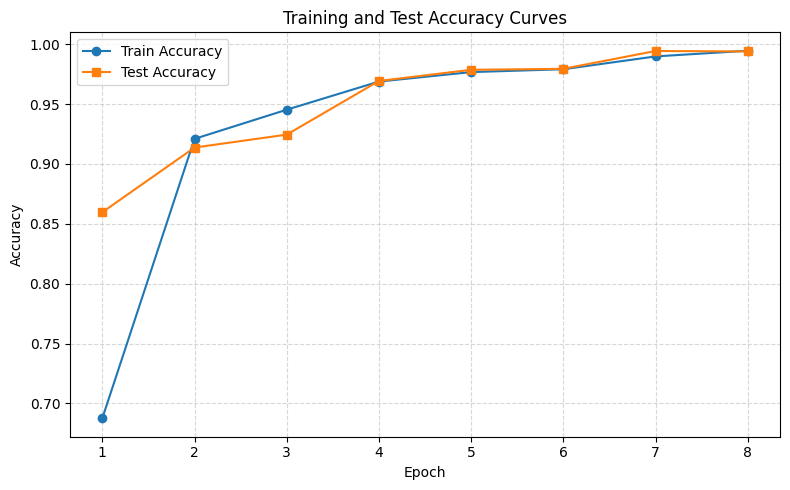

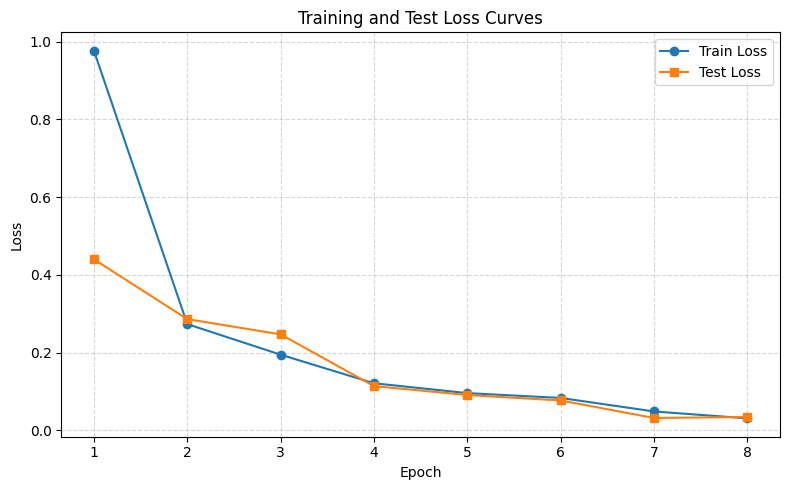

In [5]:
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_acc'], marker='o', label='Train Accuracy')
plt.plot(epochs, history['test_acc'], marker='s', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy Curves')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'resnet_accuracy_curve.png', dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epochs, history['test_loss'], marker='s', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'resnet_loss_curve.png', dpi=200)
plt.show()

## 六、实验结果汇总与分析

实验结果：最终训练准确率为99.4622%，最终测试准确率为99.4007%，最佳测试准确率为99.4392% (Epoch 7)，最终训练损失为0.0310，最终测试损失为0.0344。

分析：从两张折线图中可以看出，随着训练轮数的增加，准确率提升而损失下降；在第2轮时准确率的提升较大，对应的损失降低较大，在后面的轮次中逐渐变缓；在第8轮时模型逐渐收敛，准确率达到了99%。